## 1. Imports et Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Chargement des données préparées à l'étape 2
X = pd.read_csv('public/X_features.csv')
y = pd.read_csv('public/y_target.csv').values.ravel() # .ravel() pour transformer en array 1D

print(f"Données chargées : X {X.shape}, y {y.shape}")

Données chargées : X (1470, 40), y (1470,)


## 2. Préparation 

### 2.1 Séparation Train / Test

In [2]:
# Split 80% Train / 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")

Train set : (1176, 40)
Test set  : (294, 40)


### 2.2 Fonction d'Évaluation Standardisée

In [3]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Modele"):
    # Prédictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    print(f"--- Évaluation : {model_name} ---")
    
    # 1. Comparaison Accuracy (Pour détecter l'overfitting global)
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    print(f"Accuracy Train : {acc_train:.4f}")
    print(f"Accuracy Test  : {acc_test:.4f}")
    
    # 2. Rapport détaillé (Précision, Rappel, F1) sur le TEST
    print("\nClassification Report (Jeu de Test) :")
    print(classification_report(y_test, y_pred_test))
    
    # 3. Matrice de confusion
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()
    print("-" * 50)

## 3. Phases de tests des modèles 

### 3.1 Modèle Dummy Classifier

--- Évaluation : Dummy Classifier ---
Accuracy Train : 0.8384
Accuracy Test  : 0.8401

Classification Report (Jeu de Test) :
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       247
           1       0.00      0.00      0.00        47

    accuracy                           0.84       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.71      0.84      0.77       294



c:\Users\yanis\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yanis\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yanis\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

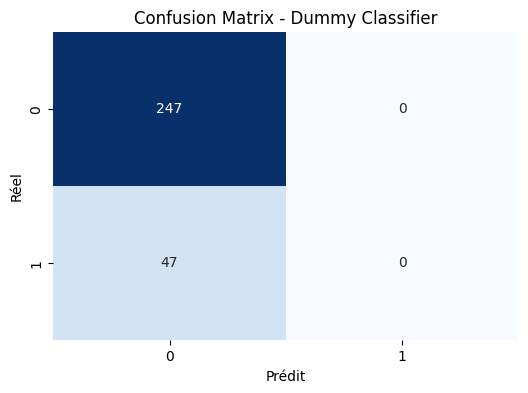

--------------------------------------------------


In [4]:
# Stratégie : 'most_frequent' (prédit toujours 0)
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

evaluate_model(dummy, X_train, y_train, X_test, y_test, "Dummy Classifier")

### 3.2 Modèle Régression linéaire

--- Évaluation : Logistic Regression ---
Accuracy Train : 0.8997
Accuracy Test  : 0.8912

Classification Report (Jeu de Test) :
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       247
           1       0.86      0.38      0.53        47

    accuracy                           0.89       294
   macro avg       0.88      0.69      0.73       294
weighted avg       0.89      0.89      0.87       294



c:\Users\yanis\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


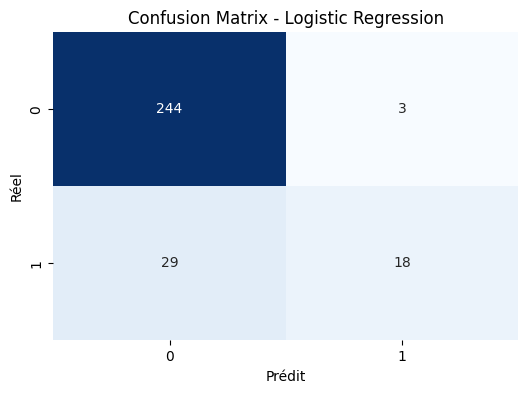

--------------------------------------------------


In [5]:
# Max_iter augmenté car le dataset peut être complexe à converger
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

evaluate_model(log_reg, X_train, y_train, X_test, y_test, "Logistic Regression")

### 3.3 Modèle Random Forest (Non-Linéaire)

--- Évaluation : Random Forest ---
Accuracy Train : 1.0000
Accuracy Test  : 0.8469

Classification Report (Jeu de Test) :
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       247
           1       0.58      0.15      0.24        47

    accuracy                           0.85       294
   macro avg       0.72      0.56      0.58       294
weighted avg       0.81      0.85      0.81       294



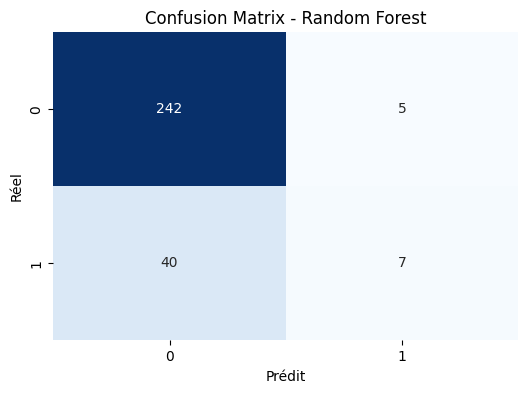

--------------------------------------------------


In [6]:
# Random Forest standard
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest")

## 4. Analyse de l'overfitting

### 1. Dummy Classifier (Baseline)
* **Performance :** Accuracy de **84%**.
* **Analyse :** Ce score correspond simplement au taux de rétention naturel de l'entreprise. Le modèle se contente de prédire "Tout le monde reste" (Recall = 0 sur la classe cible).
* **Verdict :** Il sert uniquement de seuil de référence (plancher). Tout modèle futur doit dépasser ce score et surtout détecter la classe minoritaire pour être utile.

### 2. Régression Logistique (Le modèle stable)
* **Performance :** Accuracy de **89%**. Précision de **86%** sur les départs.
* **Analyse :** C'est le modèle le plus "sain" pour l'instant. Il généralise bien (pas d'overfitting). Cependant, son **Rappel (Recall) est faible (38%)** : il manque plus de la moitié des démissionnaires.
* **Cause :** La linéarité du modèle l'empêche de capturer les combinaisons complexes (ex: "Jeune" ET "Mal payé" ET "Heures Sup").
* **Verdict :** C'est le champion actuel par défaut, fiable mais "myope".

### 3. Random Forest (Le modèle en sur-apprentissage)
* **Performance :** **100%** en entraînement vs **85%** en test.
* **Analyse :** Cas classique d'**overfitting massif**. Avec les paramètres par défaut, le modèle a appris les données par cœur. Paradoxalement, il est moins performant que la Régression Logistique pour détecter les vrais départs (Rappel de 15% contre 38%).
* **Verdict :** Inutilisable en l'état sans optimisation (GridSearch, limitation de la profondeur des arbres, gestion du déséquilibre des classes).

---

### Bilan de l'étape 3
À ce stade, la **Régression Logistique** est le modèle à privilégier. Bien que le Random Forest ait un potentiel théorique supérieur pour capturer les non-linéarités vues dans l'EDA, il échoue ici par manque de réglages (Hyperparameter Tuning).